In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for root, dirs, files in os.walk("/kaggle/working/fer2013_images"):
    if len(files) > 0:
        print(root, len(files))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/working/fer2013_images/PrivateTest/disgust 55
/kaggle/working/fer2013_images/PrivateTest/angry 491
/kaggle/working/fer2013_images/PrivateTest/surprise 416
/kaggle/working/fer2013_images/PrivateTest/neutral 626
/kaggle/working/fer2013_images/PrivateTest/happy 879
/kaggle/working/fer2013_images/PrivateTest/sad 594
/kaggle/working/fer2013_images/PrivateTest/fear 528
/kaggle/working/fer2013_images/PublicTest/disgust 56
/kaggle/working/fer2013_images/PublicTest/angry 467
/kaggle/working/fer2013_images/PublicTest/surprise 415
/kaggle/working/fer2013_images/PublicTest/neutral 607
/kaggle/working/fer2013_images/PublicTest/happy 895
/kaggle/working/fer2013_images/PublicTest/sad 653
/kaggle/working/fer2013_images/PublicTest/fear 496
/kaggle/working/fer2013_images/Training/disgust 436
/kaggle/working/fer2013_images/Training/angry 3995
/kaggle/working/fer2013_images/Training/surprise 3171
/kaggle/working/fer2013_images/Training/neutral 4965
/kaggle/working/fer2013_images/Training/happy 721

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

CSV_PATH = "/kaggle/input/datasets/elmanmarefat/fer2013/fer2013.csv"
OUTPUT_DIR = "/kaggle/working/fer2013_images"
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
df = pd.read_csv("/kaggle/input/datasets/elmanmarefat/fer2013/fer2013.csv")
print(df.head())
print(df.shape)
print(df["Usage"].value_counts())
print(df["emotion"].value_counts())

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
(35887, 3)
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


In [3]:
emotion_map = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

for usage in df["Usage"].unique():
    for emotion_name in emotion_map.values():
        os.makedirs(os.path.join(OUTPUT_DIR, usage, emotion_name), exist_ok=True)

for idx, row in tqdm(df.iterrows(), total=len(df)):
    emotion = emotion_map[row["emotion"]]
    usage = row["Usage"]

    pixels = np.array(row["pixels"].split(), dtype=np.uint8)
    image = pixels.reshape(48, 48)

    img = Image.fromarray(image)
    save_path = os.path.join(OUTPUT_DIR, usage, emotion, f"{idx}.png")
    img.save(save_path)

print("Images saved to:", OUTPUT_DIR)


100%|██████████| 35887/35887 [00:25<00:00, 1392.81it/s]

Images saved to: /kaggle/working/fer2013_images


In [4]:
base_dir = OUTPUT_DIR
for split in os.listdir(base_dir):
    split_path = os.path.join(base_dir, split)
    if os.path.isdir(split_path):
        print(f"\n{split}")
        for emotion in sorted(os.listdir(split_path)):
            emotion_path = os.path.join(split_path, emotion)
            if os.path.isdir(emotion_path):
                print(f"  {emotion}: {len(os.listdir(emotion_path))} images")


Training
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images

PrivateTest
  angry: 491 images
  disgust: 55 images
  fear: 528 images
  happy: 879 images
  neutral: 626 images
  sad: 594 images
  surprise: 416 images

PublicTest
  angry: 467 images
  disgust: 56 images
  fear: 496 images
  happy: 895 images
  neutral: 607 images
  sad: 653 images
  surprise: 415 images


In [5]:
train_dir = f"{base_dir}/Training"
val_dir = f"{base_dir}/PublicTest"
test_dir = f"{base_dir}/PrivateTest"

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset.classes
num_classes = len(class_names)

print(class_names)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 28709
Validation: 3589
Test: 3589


In [6]:
model = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.DEFAULT
)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    num_classes
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 100MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

print("Loss:", criterion)
print("Optimizer:", optimizer)
print("Epochs:", EPOCHS)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epochs: 10


In [9]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [10]:
best_val_acc = 0.0
best_model_path = "/kaggle/working/best_mobilenetv3_fer2013.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

print("Training finished.")
print("Best Validation Accuracy:", best_val_acc)


Epoch 1/10


100%|██████████| 57/57 [00:05<00:00, 10.86it/s]


Train Loss: 1.3686 | Train Acc: 0.4756
Val Loss: 1.2978 | Val Acc: 0.5146
Best model saved.

Epoch 2/10


100%|██████████| 57/57 [00:05<00:00, 10.72it/s]


Train Loss: 1.0924 | Train Acc: 0.5896
Val Loss: 1.0602 | Val Acc: 0.6049
Best model saved.

Epoch 3/10


...

Train Loss: 0.7332 | Train Acc: 0.7284
Val Loss: 0.9964 | Val Acc: 0.6542
Best model saved.

Epoch 9/10


100%|██████████| 57/57 [00:05<00:00, 10.68it/s]


Train Loss: 0.6948 | Train Acc: 0.7443
Val Loss: 1.0555 | Val Acc: 0.6333

Epoch 10/10


100%|██████████| 57/57 [00:04<00:00, 12.86it/s]

Train Loss: 0.6502 | Train Acc: 0.7600
Val Loss: 0.9932 | Val Acc: 0.6634
Best model saved.
Training finished.
Best Validation Accuracy: 0.6634159933129006


In [11]:
MODEL_PATH = "/kaggle/working/best_mobilenetv3_fer2013.pth"
model.load_state_dict(
    torch.load(MODEL_PATH, map_location = device)
)

model = model.to(device)
model.eval()


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [14]:
all_labels=[]
all_predictions=[]
all_probabilities=[]
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
print("Number of test samples:", len(all_labels))


Number of test samples: 3589


In [15]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    classification_report
)
test_accuracy = accuracy_score(all_labels, all_predictions)
macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)
macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)
macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)
print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1-score:  {macro_f1:.4f}")

Test Accuracy:  67.73%
Macro Precision: 0.6953
Macro Recall:    0.6310
Macro F1-score:  0.6501


In [18]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names = class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry     0.5913    0.6069    0.5990       491
     disgust     0.8571    0.4364    0.5783        55
        fear     0.5963    0.4223    0.4945       528
       happy     0.8793    0.8783    0.8788       879
     neutral     0.6380    0.6645    0.6510       626
         sad     0.4973    0.6296    0.5557       594
    surprise     0.8080    0.7788    0.7931       416

    accuracy                         0.6773      3589
   macro avg     0.6953    0.6310    0.6501      3589
weighted avg     0.6843    0.6773    0.6762      3589



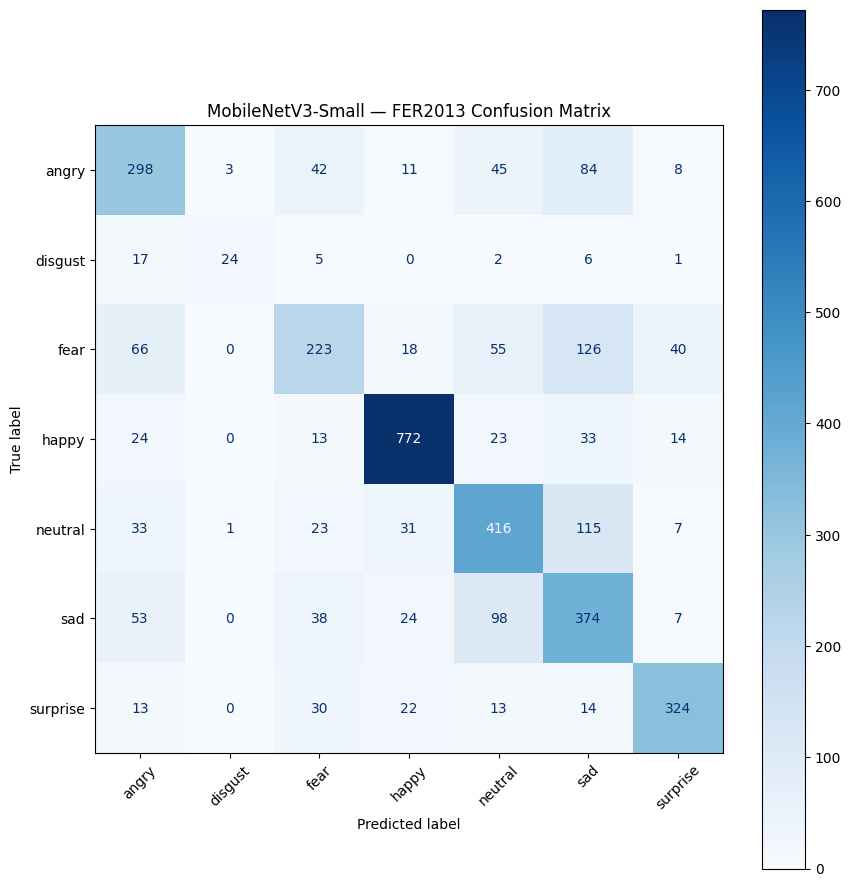

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(9,9))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)
plt.title("MobileNetV3-Small — FER2013 Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_baseline.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [25]:
baseline_results = pd.DataFrame({
    "Metric":[
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score"
    ],
    "Value":[
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
})
baseline_results

,Metric,Value
0,Test Accuracy,Test Accuracy
1,Macro Precision,Macro Precision
2,Macro Recall,Macro Recall
3,Macro F1-score,Macro F1


In [27]:
baseline_results.to_csv(
    "/kaggle/working/baseline_results.csv",
    index = False
)